In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
x,y_true = make_blobs(n_samples = 500, centers = 3, cluster_std=0.60, random_state=0)

In [8]:
df = pd.DataFrame(x, columns=['Feature_1','Feature_2'])

In [11]:
df

,Feature_1,Feature_2
0,1.052417,4.544981
1,-1.770469,3.352503
2,-1.831415,2.286754
3,1.360349,3.333614
4,-0.185498,4.417054
...,...,...
495,2.418340,1.434997
496,2.547461,1.713633
497,2.518111,1.515327
498,0.333819,4.936458


In [10]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [12]:
inertia = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [13]:
inertia

[1000.0000000000005,
 404.18148408033574,
 138.48971856185557,
 120.03296145328522,
 111.38422447852851,
 95.43625131453747,
 83.62787134261363,
 70.26414440662822,
 58.90617976644647,
 56.11013453595801]

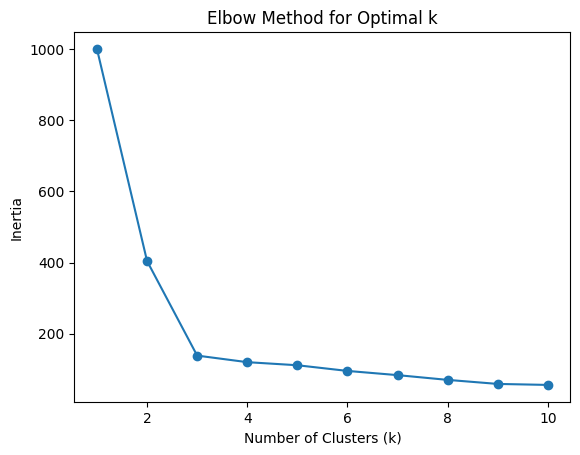

In [15]:
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [18]:
final_kmean = KMeans(n_clusters=3, random_state=42)
cluster_labels = final_kmean.fit_predict(x_scaled)

In [19]:
df['cluster'] = cluster_labels

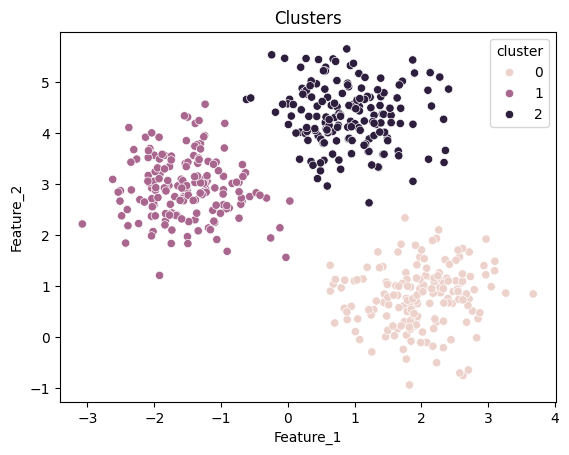

In [20]:
sns.scatterplot(x='Feature_1', y='Feature_2', hue='cluster', data=df)
plt.title('Clusters')
plt.show()
